# Inledning

Datasetet en tabell med information kring 1000 individer och hurvida man har köpt en motorcykel eller inte. Datasetet är hämtat från kaggle
Varje rad innehåller information om varje persons:
Kön
Civiltillstånd
Inkomst
Antal barn
Utbildning
Sysselsättning
Om man äger bostad
Hur många bilar
Pendlingsavstånd
Vart man bor/Region
Ålder
Om man köpt en motorcykel


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bikes = pd.read_csv("../data/bike_buyers.csv")

# Exploratory data analysis (EDA)

In [3]:
bikes.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [4]:
bikes.dtypes

ID                    int64
Marital Status          str
Gender                  str
Income              float64
Children            float64
Education               str
Occupation              str
Home Owner              str
Cars                float64
Commute Distance        str
Region                  str
Age                 float64
Purchased Bike          str
dtype: object

# Datatvätt

In [5]:
# Här kollar jag hur många värden som totalt saknas i varje kolumn. Detta för att kunna avgöra ifall de värden som saknas kan ha någon påverkan på resultaten jag får. I detta fallet blir avvikelsen försumbar.

bikes.isnull().sum()

ID                   0
Marital Status       7
Gender              11
Income               6
Children             8
Education            0
Occupation           0
Home Owner           4
Cars                 9
Commute Distance     0
Region               0
Age                  8
Purchased Bike       0
dtype: int64

In [6]:
# Jag kontrollerar om det finns rader i tabellen som är duplicerade.
bikes.duplicated().sum()

np.int64(0)

In [7]:
# Jag skapar här en tvättad kopia av tabellen. Då det var så få saknade värden i kolumnerna så tar jag bort alla rader som saknar värde i en eller flera kolumner.

clean_df = bikes.dropna()

In [8]:
# Jag kontrollerar pånytt att om det finns kolumner som saknar värde. Detta för att se så att min datatvättning fungerade.

clean_df.isnull().sum()

ID                  0
Marital Status      0
Gender              0
Income              0
Children            0
Education           0
Occupation          0
Home Owner          0
Cars                0
Commute Distance    0
Region              0
Age                 0
Purchased Bike      0
dtype: int64

# Analys

In [45]:
owns_bike = clean_df['Purchased Bike'].value_counts(ascending = True)
print(f"Amount how bought a bike: {owns_bike}")

Amount how bought a bike: Purchased Bike
Yes    456
No     496
Name: count, dtype: int64


In [28]:
owner_gender = (clean_df[clean_df['Purchased Bike'] == 'Yes']
  .groupby('Gender')
  .size()
  .rename('Owns bike')
  .reset_index()
)

owner_gender

,Gender,Owns bike
0,Female,231
1,Male,225


In [47]:
income_diff = clean_df.groupby('Gender').agg(  
  min_income   = ('Income',   'min'),
  max_income = ('Income',   'max'),
  avg_income = ('Income', 'mean'),
).round(2)

print(f"Difference in income: \n\n{income_diff}")

Difference in income: 

        min_income  max_income  avg_income
Gender                                    
Female     10000.0    170000.0    54566.60
Male       10000.0    170000.0    57223.38


In [33]:
region = (clean_df.groupby('Purchased Bike')['Region'].value_counts())

region

Purchased Bike  Region       
No              North America    275
                Europe           147
                Pacific           74
Yes             North America    211
                Europe           139
                Pacific          106
Name: count, dtype: int64

# Visualisering

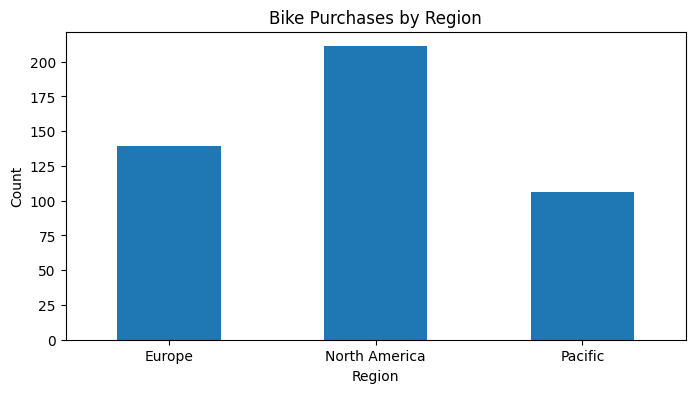

In [ ]:
purchase_by_region = (clean_df[clean_df['Purchased Bike'] == 'Yes']
  .groupby('Region')
  .size()
)

purchase_by_region.plot(kind='bar', figsize=(8, 4))
plt.title('Bike Purchases by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()